# Mouse Brain Spatial Multiome Model Comparison

This notebook:
1. Loads the Mouse Brain Spatial Multiome dataset (RNA + ATAC with spatial coordinates).
2. Loads all trained topic models under `/data/omics_topic_models/mouse_brain_spatial`.
3. Selects the best model by spatial autocorrelation (Moran's I on clustering assignments).
4. Loads baseline models: SpatialGlue, STAMP, MultiVI, and MOFA+.
5. Compares all models via UMAP and spatial plots colored by Leiden clustering.
6. Evaluates spatial coherence metrics for each embedding.

In [ ]:
import os
import sys
import re
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import mudata as md
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.sparse as sp
import squidpy as sq
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

# Data paths
RNA_PATH = "/data/Data_SpatialGlue/Dataset10_Mouse_Brain_H3K27me3/adata_RNA.h5ad"
ATAC_PATH = "/data/Data_SpatialGlue/Dataset10_Mouse_Brain_H3K27me3/adata_peaks_normalized.h5ad"

# Omics-topic model directories
MODELS_DIR = Path("/data/omics_topic_models/mouse_brain_spatial_gcn_2")
MODELS_DIR_GC = Path("/data/omics_topic_models/mouse_brain_spatial_graphconv")
MODELS_DIR_MF = Path("/data/omics_topic_models/mouse_brain_spatial_meanfield")

# Baselines (trained in the original dir)
BASELINES_DIR = Path("/data/omics_topic_models/mouse_brain_spatial/baselines")

## 1. Load Mouse Brain Spatial Multiome data

In [19]:
from omics_topic import MultimodalAmortizedLDA


def ensure_counts_layer(adata):
    if "counts" not in adata.layers:
        adata.layers["counts"] = adata.X.copy()


def binarize_atac(adata_atac):
    X = adata_atac.X
    if sp.issparse(X):
        X = X.tocsr(copy=True)
        X.data = np.ones_like(X.data)
        X.eliminate_zeros()
        adata_atac.layers["binary"] = X
    else:
        adata_atac.layers["binary"] = (X != 0).astype(np.float32)


def load_data():
    """Load and preprocess Mouse Brain Spatial Multiome data."""
    adata_rna = sc.read_h5ad(RNA_PATH)
    adata_atac = sc.read_h5ad(ATAC_PATH)

    # Ensure counts layer for RNA
    ensure_counts_layer(adata_rna)

    # Binarize ATAC data
    binarize_atac(adata_atac)

    # Create MuData
    mdata = md.MuData({"rna": adata_rna, "atac": adata_atac})

    # Build spatial neighbor graph from RNA coordinates
    sc.pp.neighbors(
        mdata.mod["rna"],
        use_rep="spatial",
        n_neighbors=5,
        metric="euclidean",
        key_added="spatial",
    )

    # Share spatial connectivities across modalities
    mdata.obsp["spatial_connectivities"] = mdata.mod["rna"].obsp["spatial_connectivities"]
    mdata.mod["atac"].obsp["spatial_connectivities"] = mdata.mod["rna"].obsp[
        "spatial_connectivities"
    ]
    mdata.mod["atac"].obsp["spatial_distances"] = mdata.mod["rna"].obsp["spatial_distances"]

    # Store spatial coordinates at MuData level
    mdata.obsm["spatial"] = mdata.mod["rna"].obsm["spatial"]

    print(f"RNA: {mdata.mod['rna'].shape}")
    print(f"ATAC: {mdata.mod['atac'].shape}")
    print(f"Total spots: {mdata.n_obs}")

    return mdata


mdata = load_data()
spatial_coords = mdata.obsm["spatial"]

RNA: (9752, 25881)
ATAC: (9752, 70470)
Total spots: 9752


## 2. Load all trained topic models and compute spatial autocorrelation

In [20]:
def parse_model_config(dirname):
    """Parse hyperparameter configuration from directory name."""
    config = {}
    if "horseshoe" in dirname:
        config["feature_prior_type"] = "horseshoe"
    else:
        config["feature_prior_type"] = "logistic_normal"

    if "weight_cell" in dirname:
        config["weight_mode"] = "cell"
    elif "weight_universal" in dirname:
        config["weight_mode"] = "universal"
    else:
        config["weight_mode"] = "equal"

    if "learnable_disp_global" in dirname:
        config["dispersion"] = "learnable_global"
    elif "learnable_disp_pergene" in dirname:
        config["dispersion"] = "learnable_pergene"
    else:
        config["dispersion"] = "fixed"

    match = re.search(r"_gcn(\d+)", dirname)
    if match:
        config["gcn_n_layers"] = int(match.group(1))
    else:
        config["gcn_n_layers"] = 1

    return config


def compute_moran_i(values, spatial_weights):
    """
    Compute Moran's I statistic for a 1D array of values.
    """
    n = len(values)
    z = values - values.mean()
    
    W = spatial_weights.tocsr()
    numerator = z @ W @ z
    denominator = z @ z
    
    if denominator == 0:
        return 0.0
    
    S0 = W.sum()
    if S0 == 0:
        return 0.0
    
    return (n / S0) * (numerator / denominator)


def compute_spatial_metrics(latent, spatial_coords, n_neighbors=6):
    """
    Compute spatial autocorrelation (Moran's I) and Leiden clustering on latent space.
    Returns mean Moran's I across all latent dimensions.
    """
    adata = ad.AnnData(np.asarray(latent))
    adata.obsm["spatial"] = np.asarray(spatial_coords)

    # Leiden clustering
    sc.pp.neighbors(adata, use_rep="X", n_neighbors=15, metric="cosine")
    sc.tl.leiden(adata, key_added="leiden", resolution=0.5)

    # Build spatial graph for Moran's I
    sq.gr.spatial_neighbors(adata, n_neighs=n_neighbors, coord_type="generic")
    spatial_weights = adata.obsp["spatial_connectivities"]
    
    # Compute Moran's I for each latent dimension
    morans_values = [compute_moran_i(latent[:, i], spatial_weights) for i in range(latent.shape[1])]

    return {
        "morans_i": np.mean(morans_values),
        "n_clusters": len(adata.obs["leiden"].unique()),
        "leiden": adata.obs["leiden"].values
    }


def compute_topic_spatial_coherence(latent, spatial_coords, n_neighbors=6):
    """Mean Moran's I across latent dimensions (topic coherence proxy)."""
    spatial_metrics = compute_spatial_metrics(latent, spatial_coords, n_neighbors=n_neighbors)
    return float(spatial_metrics["morans_i"])


In [ ]:
# Find all model directories (gcn_2 + graphconv + meanfield)
model_dirs = []
for mdir, suffix in [(MODELS_DIR, "_gcn2"), (MODELS_DIR_GC, "_gc"), (MODELS_DIR_MF, "_mf")]:
    if not mdir.exists():
        print(f"Warning: Models directory does not exist: {mdir}")
        continue
    for d in sorted(mdir.iterdir()):
        if d.is_dir() and d.name.startswith("prior_"):
            model_dirs.append((d, suffix))

print(f"Found {len(model_dirs)} candidate model dirs")

# Prepare data for model loading - IMPORTANT: include spatial_keys for spatial models
if model_dirs:
    mdata_setup, modality_names, feat_counts = MultimodalAmortizedLDA.setup_mudata(
        mdata,
        modality_order=["rna", "atac"],
        layers={"rna": None, "atac": "binary"},
        spatial_keys="spatial_connectivities",  # Required for spatial models with GCN
    )
    adata_flat = mdata.uns["_flattened_ann_data"]
    
    # Verify spatial connectivities are in the flattened AnnData
    if "spatial_connectivities" in adata_flat.obsp:
        print(f"Spatial connectivities available: {adata_flat.obsp['spatial_connectivities'].shape}")
    else:
        print("Warning: spatial_connectivities not found in flattened AnnData")

In [ ]:
results = []

for model_dir, suffix in model_dirs:
    model_path = model_dir / "model"
    if not model_path.exists():
        continue

    display_name = model_dir.name + suffix
    print(f"Loading {display_name}...")
    
    # First, try to load pre-saved latent representation if available
    latent_path = model_dir / "latent_representation.npy"
    theta_path = model_dir / "theta.npy"
    
    theta_array = None
    
    # Check for pre-saved latent representations
    if latent_path.exists():
        theta_array = np.load(latent_path)
        print(f"  Loaded pre-saved latent from {latent_path}")
    elif theta_path.exists():
        theta_array = np.load(theta_path)
        print(f"  Loaded pre-saved theta from {theta_path}")
    
    # If no pre-saved latent, try loading the model
    if theta_array is None:
        try:
            model = MultimodalAmortizedLDA.load(str(model_path), adata=adata_flat)
            theta = model.get_latent_representation(batch_size=mdata.n_obs)
            theta_array = np.asarray(theta)
            
            # Save for future use
            np.save(latent_path, theta_array)
            print(f"  Loaded from model and saved latent to {latent_path}")
        except Exception as e:
            print(f"  Error loading model: {e}")
            continue
    
    config = parse_model_config(model_dir.name)
    config["elbo"] = "TraceMeanField" if suffix == "_mf" else "Trace"

    try:
        # Spatial autocorrelation
        spatial_metrics = compute_spatial_metrics(theta_array, spatial_coords)
        topic_morans = compute_topic_spatial_coherence(theta_array, spatial_coords)

        result = {
            "model_name": display_name,
            **config,
            "morans_i": spatial_metrics["morans_i"],
            "topic_morans_i": topic_morans,
            "n_clusters": spatial_metrics["n_clusters"],
            "theta": theta_array,
            "leiden": spatial_metrics["leiden"],
        }
        results.append(result)

        print(
            f"  Moran's I: {spatial_metrics['morans_i']:.4f}, "
            f"Topic Moran's I: {topic_morans:.4f}"
        )
    except Exception as e:
        print(f"  Error computing metrics: {e}")
        import traceback
        traceback.print_exc()

print(f"\nSuccessfully loaded {len(results)} models")

## 3. Select best model by spatial autocorrelation

In [23]:
if results:
    results_display = [{k: v for k, v in r.items() if k not in ["theta", "leiden"]} for r in results]
    df_results = pd.DataFrame(results_display)

    # Sort by Moran's I (spatial autocorrelation) - higher is better
    df_sorted = df_results.sort_values("topic_morans_i", ascending=False)
    print("Model Comparison (sorted by Topic Moran's I):")
    print(df_sorted.to_string(index=False))

    best_idx = df_sorted["topic_morans_i"].idxmax()
    best_model_name = df_sorted.loc[best_idx, "model_name"]
    best_result = next(r for r in results if r["model_name"] == best_model_name)

    print(f"\nBest model: {best_model_name}")
    print(f"  Feature prior: {best_result['feature_prior_type']}")
    print(f"  Weight mode: {best_result['weight_mode']}")
    print(f"  GCN layers: {best_result.get('gcn_n_layers', 1)}")
    print(f"  Dispersion: {best_result['dispersion']}")
    print(f"  Topic Moran's I: {best_result['topic_morans_i']:.4f}")
    print(f"  Latent Moran's I: {best_result['morans_i']:.4f}")

    theta_best = best_result["theta"]
else:
    print("No topic models loaded.")
    print("This could be because:")
    print("  1. No models were trained yet (run train_mouse_brain_spatial.py first)")
    print("  2. Trained models don't have latent_representation.npy saved")
    print("     (re-run training with updated script that saves latents)")
    print("  3. Model loading failed due to architecture mismatch")
    theta_best = None
    df_sorted = None


Model Comparison (sorted by Topic Moran's I):
                                     model_name feature_prior_type weight_mode dispersion  gcn_n_layers  morans_i  topic_morans_i  n_clusters
prior_logistic_normal_weight_universal_gcn2_gcn    logistic_normal   universal      fixed             2  0.600277        0.600277          12

Best model: prior_logistic_normal_weight_universal_gcn2_gcn
  Feature prior: logistic_normal
  Weight mode: universal
  GCN layers: 2
  Dispersion: fixed
  Topic Moran's I: 0.6003
  Latent Moran's I: 0.6003


In [24]:
# Visualize results
if results and len(results) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    df_pivot = df_sorted.pivot_table(
        values="topic_morans_i", index="feature_prior_type", columns="weight_mode", aggfunc="mean"
    )
    sns.heatmap(df_pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title("Topic Moran's I by Prior Type and Weight Mode")

    ax = axes[1]
    colors = df_sorted["feature_prior_type"].map({"logistic_normal": "blue", "horseshoe": "red"})
    ax.scatter(df_sorted["morans_i"], df_sorted["topic_morans_i"], c=colors, s=100, alpha=0.7)
    ax.set_xlabel("Latent Moran's I")
    ax.set_ylabel("Topic Moran's I")
    ax.set_title("Latent vs Topic Spatial Autocorrelation")
    ax.legend(
        handles=[
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="blue", markersize=10, label="Logistic Normal"),
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=10, label="Horseshoe"),
        ]
    )

    plt.tight_layout()
    plt.show()
elif results:
    print("Only one model loaded, skipping comparison visualization")

Only one model loaded, skipping comparison visualization


## 4. Load baseline models

In [ ]:
# Load SpatialGlue latent
latent_spatialglue = None
spatialglue_path = BASELINES_DIR / "latent_spatialglue.npy"
if spatialglue_path.exists():
    latent_spatialglue = np.load(spatialglue_path)
    print(f"Loaded SpatialGlue latent: {latent_spatialglue.shape}")
else:
    print(f"SpatialGlue latent not found: {spatialglue_path}")

# Load STAMP latent
latent_stamp = None
stamp_path = BASELINES_DIR / "latent_stamp.npy"
if stamp_path.exists():
    latent_stamp = np.load(stamp_path)
    print(f"Loaded STAMP latent: {latent_stamp.shape}")
else:
    print(f"STAMP latent not found: {stamp_path}")

# Load MultiVI latent
latent_multivi = None
multivi_path = BASELINES_DIR / "latent_multivi.npy"
if multivi_path.exists():
    latent_multivi = np.load(multivi_path)
    print(f"Loaded MultiVI latent: {latent_multivi.shape}")
else:
    print(f"MultiVI latent not found: {multivi_path}")

# Load MOFA+ latent
latent_mofa = None
mofa_latent_path = BASELINES_DIR / "latent_mofa.npy"
mofa_mdata_path = BASELINES_DIR / "mdata_mofa.h5mu"
if mofa_latent_path.exists():
    latent_mofa = np.load(mofa_latent_path)
    print(f"Loaded MOFA+ latent: {latent_mofa.shape}")
elif mofa_mdata_path.exists():
    mdata_mofa = mu.read_h5mu(mofa_mdata_path)
    latent_mofa = np.asarray(mdata_mofa.obsm["X_mofa"])
    print(f"Loaded MOFA+ latent from MuData: {latent_mofa.shape}")
else:
    print(f"MOFA+ latent not found")

## 5. Compute spatial metrics for all models

In [26]:
def compute_metrics_for_latent(latent, name, spatial_coords):
    """Compute spatial autocorrelation metrics for a latent representation."""
    if latent is None:
        return None

    print(f"Computing metrics for {name}...")
    try:
        spatial_metrics = compute_spatial_metrics(latent, spatial_coords)
        topic_morans = compute_topic_spatial_coherence(latent, spatial_coords)
        return {
            "model": name,
            "morans_i": spatial_metrics["morans_i"],
            "topic_morans_i": topic_morans,
            "n_clusters": spatial_metrics["n_clusters"],
            "latent": latent,
            "leiden": spatial_metrics["leiden"],
        }
    except Exception as e:
        print(f"  Error computing metrics: {e}")
        return None


baseline_results = {}

# Compute metrics for baselines
if latent_spatialglue is not None:
    baseline_results["SpatialGlue"] = compute_metrics_for_latent(
        latent_spatialglue, "SpatialGlue", spatial_coords
    )

if latent_stamp is not None:
    baseline_results["STAMP"] = compute_metrics_for_latent(
        latent_stamp, "STAMP", spatial_coords
    )

if latent_multivi is not None:
    baseline_results["MultiVI"] = compute_metrics_for_latent(
        latent_multivi, "MultiVI", spatial_coords
    )

if latent_mofa is not None:
    baseline_results["MOFA+"] = compute_metrics_for_latent(
        latent_mofa, "MOFA+", spatial_coords
    )

# Add best topic model
if theta_best is not None:
    baseline_results["Topic Model (Best)"] = {
        "model": "Topic Model (Best)",
        "morans_i": best_result["morans_i"],
        "topic_morans_i": best_result["topic_morans_i"],
        "n_clusters": best_result["n_clusters"],
        "latent": theta_best,
        "leiden": best_result["leiden"],
    }


In [27]:
# Summary comparison table
if baseline_results:
    summary_data = []
    for name, res in baseline_results.items():
        if res is not None:
            summary_data.append({
                "Model": res["model"],
                "Latent Moran's I": res["morans_i"],
                "Topic Moran's I": res["topic_morans_i"],
                "N Clusters": res["n_clusters"],
            })

    summary_df = pd.DataFrame(summary_data).sort_values("Topic Moran's I", ascending=False)
    print("\nSpatial Autocorrelation Comparison:")
    print(summary_df.to_string(index=False))
else:
    print("No models loaded for comparison.")
    summary_df = None


Spatial Autocorrelation Comparison:
             Model  Latent Moran's I  Topic Moran's I  N Clusters
Topic Model (Best)          0.600277         0.600277          12


## 6. Plot performance comparison

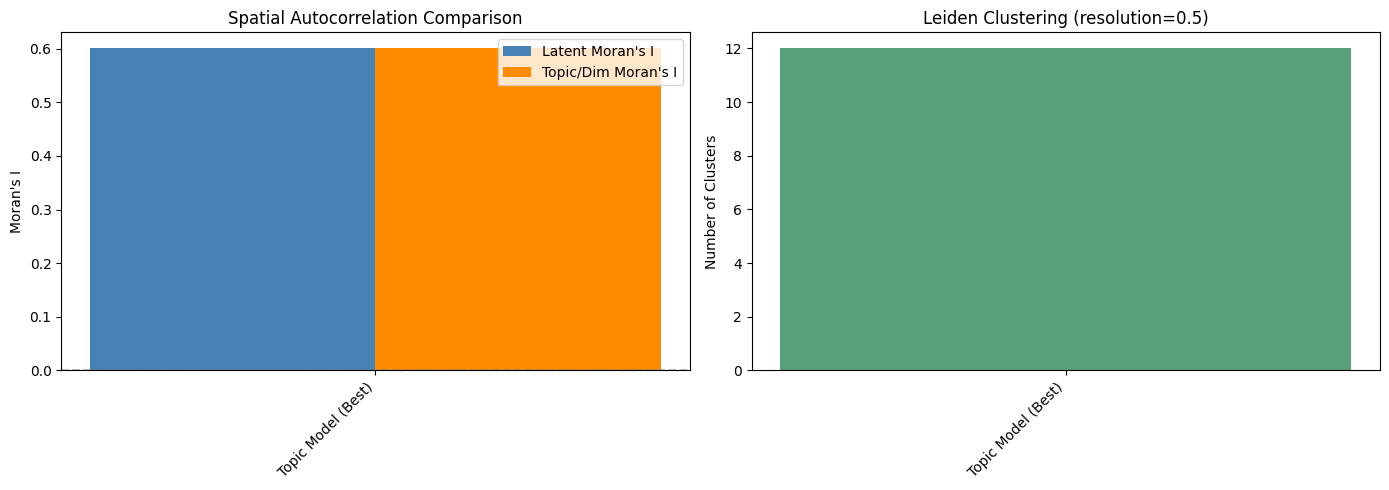


Saved comparison plot to: /data/omics_topic_models/mouse_brain_spatial_gcn_2/baselines/spatial_comparison.png


In [28]:
if summary_df is not None and len(summary_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Moran's I comparison
    ax = axes[0]
    x = np.arange(len(summary_df))
    width = 0.35
    ax.bar(x - width/2, summary_df["Latent Moran's I"], width, label="Latent Moran's I", color="steelblue")
    ax.bar(x + width/2, summary_df["Topic Moran's I"], width, label="Topic/Dim Moran's I", color="darkorange")
    ax.set_ylabel("Moran's I")
    ax.set_title("Spatial Autocorrelation Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df["Model"], rotation=45, ha="right")
    ax.legend()
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)

    # Number of clusters
    ax = axes[1]
    ax.bar(summary_df["Model"], summary_df["N Clusters"], color="seagreen", alpha=0.8)
    ax.set_ylabel("Number of Clusters")
    ax.set_title("Leiden Clustering (resolution=0.5)")
    ax.set_xticklabels(summary_df["Model"], rotation=45, ha="right")

    plt.tight_layout()

    # Save figure
    BASELINES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(BASELINES_DIR / "spatial_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(f"\nSaved comparison plot to: {BASELINES_DIR / 'spatial_comparison.png'}")

## 7. UMAP and Spatial plots for all models

In [ ]:
def plot_umap_and_spatial(latent, leiden, spatial_coords, title, figsize=(14, 5)):
    """
    Plot UMAP and spatial coordinates colored by Leiden clustering.
    """
    # Create AnnData
    adata = ad.AnnData(np.asarray(latent))
    adata.obsm["spatial"] = np.asarray(spatial_coords)
    adata.obs["leiden"] = pd.Categorical(leiden)

    # Compute UMAP
    sc.pp.neighbors(adata, use_rep="X", n_neighbors=15, metric="cosine")
    sc.tl.umap(adata, min_dist=0.3)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # UMAP
    sc.pl.umap(adata, color="leiden", ax=axes[0], show=False, title=f"{title}: UMAP")

    # Spatial plot
    scatter = axes[1].scatter(
        spatial_coords[:, 0],
        spatial_coords[:, 1],
        c=leiden.astype(int) if not isinstance(leiden[0], str) else LabelEncoder().fit_transform(leiden),
        cmap="tab20",
        s=10,
        alpha=0.8,
    )
    axes[1].set_title(f"{title}: Spatial")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    axes[1].set_aspect("equal")
    axes[1].invert_xaxis()

    plt.tight_layout()
    return fig, adata


Plotting Topic Model (Best)...


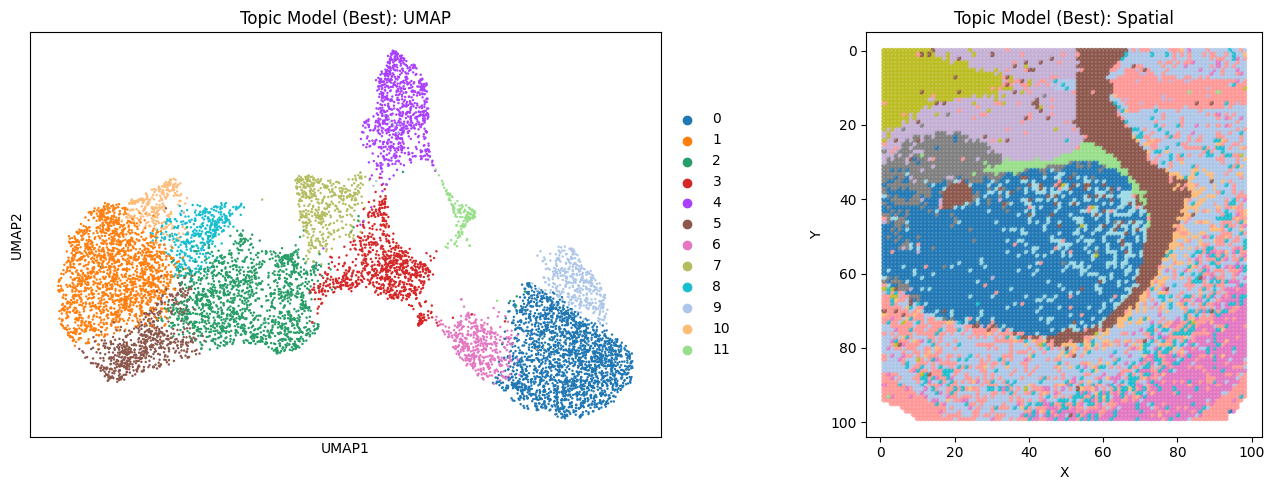

  Saved to: /data/omics_topic_models/mouse_brain_spatial_gcn_2/baselines/umap_spatial_topic_model_best.png


In [30]:
# Plot for all models
all_figures = {}

for name, res in baseline_results.items():
    if res is not None:
        print(f"\nPlotting {name}...")
        fig, adata = plot_umap_and_spatial(
            res["latent"],
            res["leiden"],
            spatial_coords,
            name,
        )
        all_figures[name] = fig
        plt.show()

        # Save individual figures
        safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
        fig.savefig(BASELINES_DIR / f"umap_spatial_{safe_name}.png", dpi=200, bbox_inches="tight")
        print(f"  Saved to: {BASELINES_DIR / f'umap_spatial_{safe_name}.png'}")

## 8. Combined comparison figure

In [ ]:
# Create a combined figure with all models
n_models = len([r for r in baseline_results.values() if r is not None])

if n_models > 0:
    fig, axes = plt.subplots(n_models, 2, figsize=(12, 4 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)

    for idx, (name, res) in enumerate([(k, v) for k, v in baseline_results.items() if v is not None]):
        latent = res["latent"]
        leiden = res["leiden"]

        # Create temporary AnnData for UMAP
        adata_temp = ad.AnnData(np.asarray(latent))
        adata_temp.obsm["spatial"] = np.asarray(spatial_coords)
        adata_temp.obs["leiden"] = pd.Categorical(leiden)

        sc.pp.neighbors(adata_temp, use_rep="X", n_neighbors=15, metric="cosine")
        sc.tl.umap(adata_temp, min_dist=0.3)

        # UMAP
        sc.pl.umap(adata_temp, color="leiden", ax=axes[idx, 0], show=False, title=f"{name}: UMAP")

        # Spatial
        leiden_encoded = leiden.astype(int) if not isinstance(leiden[0], str) else LabelEncoder().fit_transform(leiden)
        axes[idx, 1].scatter(
            spatial_coords[:, 0],
            spatial_coords[:, 1],
            c=leiden_encoded,
            cmap="tab20",
            s=8,
            alpha=0.8,
        )
        axes[idx, 1].set_title(f"{name}: Spatial (Moran's I={res['topic_morans_i']:.3f})")
        axes[idx, 1].set_aspect("equal")
        axes[idx, 1].invert_xaxis()
        axes[idx, 1].set_xlabel("X")
        axes[idx, 1].set_ylabel("Y")

    plt.tight_layout()
    fig.savefig(BASELINES_DIR / "combined_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(f"\nSaved combined comparison to: {BASELINES_DIR / 'combined_comparison.png'}")

## 9. Save results

In [ ]:
# Save summary tables
BASELINES_DIR.mkdir(parents=True, exist_ok=True)

if summary_df is not None:
    summary_df.to_csv(BASELINES_DIR / "spatial_metrics_comparison.csv", index=False)
    print(f"Saved comparison metrics to: {BASELINES_DIR / 'spatial_metrics_comparison.csv'}")

if results:
    results_display = [{k: v for k, v in r.items() if k not in ["theta", "leiden"]} for r in results]
    pd.DataFrame(results_display).to_csv(BASELINES_DIR / "topic_model_metrics.csv", index=False)
    print(f"Saved topic model metrics to: {BASELINES_DIR / 'topic_model_metrics.csv'}")

## Notes

- This notebook expects trained topic models under `/data/omics_topic_models/mouse_brain_spatial` with `prior_*` directories.
- Baseline outputs are expected under `/data/omics_topic_models/mouse_brain_spatial/baselines`.
- The best model is selected by **Topic Moran's I**, which measures spatial autocorrelation of topic proportions.
- Higher Moran's I indicates topics capture spatial structure better.
- STAMP only uses RNA data, while SpatialGlue, MultiVI, and MOFA+ use both RNA and ATAC.

### Troubleshooting Model Loading

If topic models fail to load with architecture errors (GCN encoders), this is because spatial models 
have a different architecture than non-spatial models. Solutions:

1. **Re-run training** with the updated `train_mouse_brain_spatial.py` script which now saves 
   `latent_representation.npy` alongside each model.

2. **Manually save latent representations** for already-trained models by running inference 
   with the correct setup (see helper cell below if needed).

In [33]:
# HELPER: Extract and save latent representations from already-trained models
# Run this cell only if models were trained but latent_representation.npy was not saved

EXTRACT_LATENTS = False  # Set to True to run extraction

if EXTRACT_LATENTS and model_dirs:
    print("Extracting latent representations from trained models...")
    print("This requires proper setup with spatial connectivities.")
    
    for model_dir in model_dirs:
        model_path = model_dir / "model"
        latent_path = model_dir / "latent_representation.npy"
        
        if not model_path.exists():
            continue
        if latent_path.exists():
            print(f"  {model_dir.name}: latent already exists, skipping")
            continue
            
        print(f"  Processing {model_dir.name}...")
        try:
            # Load model with full spatial setup
            model = MultimodalAmortizedLDA.load(str(model_path), adata=adata_flat)
            theta = model.get_latent_representation(batch_size=mdata.n_obs)
            np.save(latent_path, theta.values)
            print(f"    Saved latent to {latent_path}")
        except Exception as e:
            print(f"    Failed: {e}")
            print("    You may need to manually re-run training for this model")

## 10. Best Topic Model Diagnostics


INFO     File                                                                                                      
         /data/omics_topic_models/mouse_brain_spatial_gcn_2/prior_logistic_normal_weight_universal_gcn2_gcn/model/m
         odel.pt already downloaded                                                                                


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/1000:   0%|          | 1/1000 [00:00<02:23,  6.98it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<02:35,  6.42it/s, v_num=1]
GCN skip connection weights (alpha):
modality  alpha_skip_weight  neighbor_weight
     rna           0.478040         0.521960
    atac           0.302034         0.697966


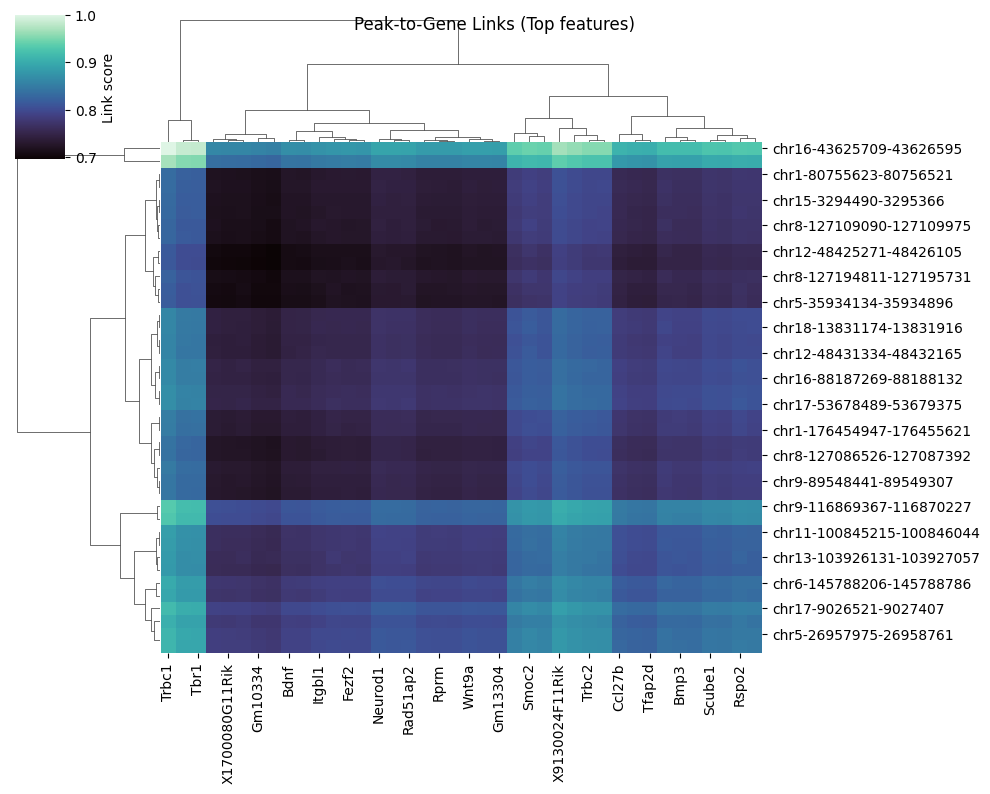

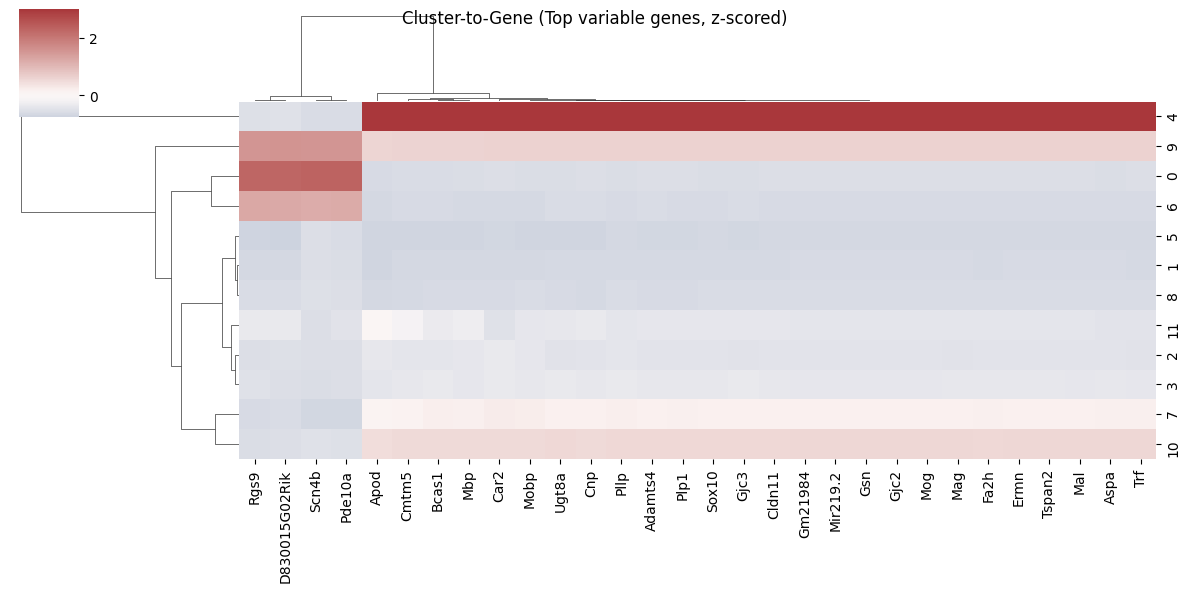

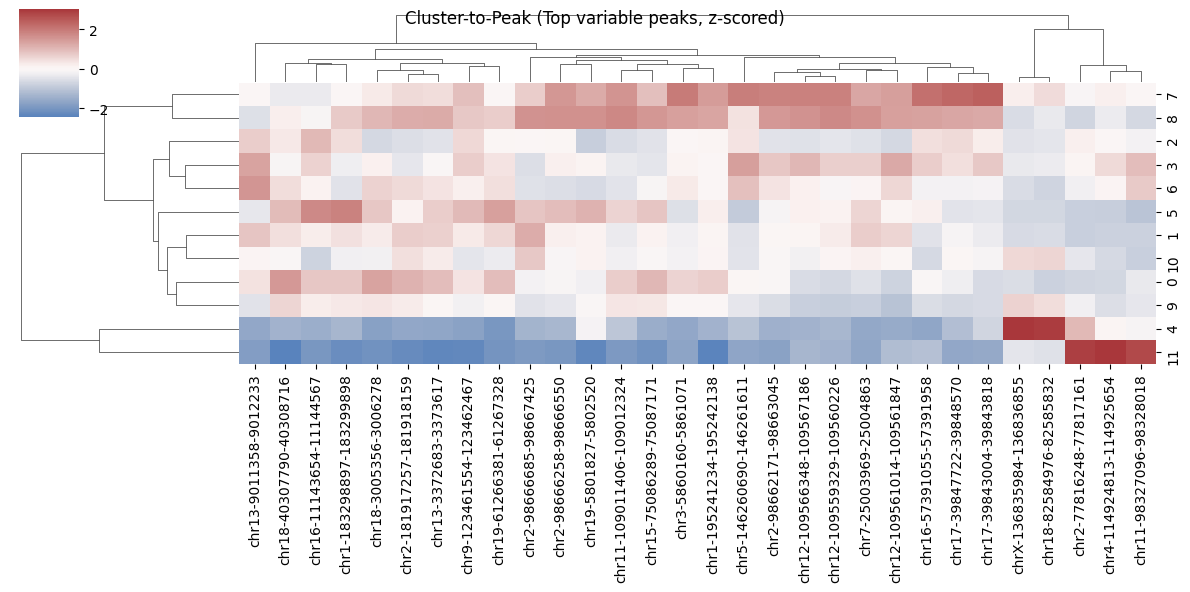

: 

In [ ]:
# Diagnostics for the best topic model (requires the model to be loadable)
if theta_best is None:
    print("Best topic model not available; skipping diagnostics.")
else:
    best_model_dir = MODELS_DIR / best_model_name
    model_path = best_model_dir / "model"
    best_model = None
    if model_path.exists():
        try:
            best_model = MultimodalAmortizedLDA.load(str(model_path), adata=adata_flat)
        except Exception as e:
            print(f"Could not load best model for diagnostics: {e}")
    else:
        print(f"Model path not found: {model_path}")

    if best_model is None:
        print("Skipping diagnostics that require the loaded model.")
    else:
        # 1) GCN skip connection weights (alpha)
        gcn_encoders = getattr(best_model.module.guide, "gcn_encoders", None)
        if gcn_encoders:
            mod_names = getattr(best_model, "modality_names", None) or [f"mod_{i}" for i in range(len(gcn_encoders))]
            alphas = [enc.alpha for enc in gcn_encoders]
            alpha_df = pd.DataFrame({
                "modality": mod_names,
                "alpha_skip_weight": alphas,
                "neighbor_weight": [1 - a for a in alphas],
            })
            print("GCN skip connection weights (alpha):")
            print(alpha_df.to_string(index=False))
        else:
            print("No GCN encoders found; skip alpha report.")

        # Helper to normalize topic-feature matrices to (topics x features)
        def _normalize_phi(phi, n_topics):
            names = None
            if isinstance(phi, pd.DataFrame):
                if phi.shape[1] == n_topics:
                    names = phi.index.tolist()
                    return phi.values.T, names
                if phi.shape[0] == n_topics:
                    names = phi.columns.tolist()
                    return phi.values, names
            arr = np.asarray(phi)
            if arr.shape[0] == n_topics:
                return arr, names
            return arr.T, names

        # Helper for z-scoring across clusters
        def _zscore_cols(matrix):
            mean = matrix.mean(axis=0, keepdims=True)
            std = matrix.std(axis=0, keepdims=True) + 1e-8
            return (matrix - mean) / std

        # 2) Peak-to-gene links heatmap (clustered)
        try:
            mod_atac = "atac" if "atac" in best_model.modality_names else "chromatin"
            peak_gene = best_model.cross_modality_score(mod_atac, "rna", normalise=True, return_df=True)
            top_peaks = peak_gene.max(axis=1).nlargest(40).index
            top_genes = peak_gene.max(axis=0).nlargest(40).index
            peak_gene_sub = peak_gene.loc[top_peaks, top_genes]
            cg = sns.clustermap(
                peak_gene_sub,
                cmap="mako",
                figsize=(10, 8),
                row_cluster=True,
                col_cluster=True,
                cbar_kws={"label": "Link score"},
            )
            cg.fig.suptitle("Peak-to-Gene Links (Top features)")
            plt.show()
        except Exception as e:
            print(f"Peak-to-gene heatmap failed: {e}")

        # 3) Cluster-to-gene and cluster-to-peak heatmaps (clustered, z-scored)
        try:
            theta = np.asarray(theta_best)
            clusters = pd.Categorical(best_result["leiden"])
            cluster_ids = clusters.categories

            cluster_topic = []
            for cl in cluster_ids:
                mask = clusters == cl
                if mask.sum() == 0:
                    cluster_topic.append(np.zeros(theta.shape[1]))
                else:
                    cluster_topic.append(theta[mask].mean(axis=0))
            cluster_topic = np.vstack(cluster_topic)

            phi_rna = best_model.get_feature_topic_dist("rna")
            phi_atac = best_model.get_feature_topic_dist(mod_atac)
            phi_rna_arr, gene_names = _normalize_phi(phi_rna, theta.shape[1])
            phi_atac_arr, peak_names = _normalize_phi(phi_atac, theta.shape[1])

            cluster_gene = cluster_topic @ phi_rna_arr
            cluster_peak = cluster_topic @ phi_atac_arr

            gene_idx = np.argsort(cluster_gene.var(axis=0))[-30:]
            peak_idx = np.argsort(cluster_peak.var(axis=0))[-30:]

            gene_cols = np.array(gene_names)[gene_idx] if gene_names else gene_idx
            peak_cols = np.array(peak_names)[peak_idx] if peak_names else peak_idx

            cluster_gene_df = pd.DataFrame(cluster_gene[:, gene_idx], index=cluster_ids, columns=gene_cols)
            cluster_peak_df = pd.DataFrame(cluster_peak[:, peak_idx], index=cluster_ids, columns=peak_cols)

            cluster_gene_z = _zscore_cols(cluster_gene_df.values)
            cluster_peak_z = _zscore_cols(cluster_peak_df.values)

            cg_gene = sns.clustermap(
                pd.DataFrame(cluster_gene_z, index=cluster_ids, columns=gene_cols),
                cmap="vlag",
                center=0.0,
                figsize=(12, 6),
                row_cluster=True,
                col_cluster=True,
            )
            cg_gene.fig.suptitle("Cluster-to-Gene (Top variable genes, z-scored)")
            plt.show()

            cg_peak = sns.clustermap(
                pd.DataFrame(cluster_peak_z, index=cluster_ids, columns=peak_cols),
                cmap="vlag",
                center=0.0,
                figsize=(12, 6),
                row_cluster=True,
                col_cluster=True,
            )
            cg_peak.fig.suptitle("Cluster-to-Peak (Top variable peaks, z-scored)")
            plt.show()
        except Exception as e:
            print(f"Cluster heatmaps failed: {e}")
